# Confirmatory Analysis 07 — Market Cointegration EUR/USD

**Goal:** Confirm whether the Scryfall EUR, Cardmarket EUR, and TCGPlayer USD price series are cointegrated — i.e. they share a long-run equilibrium despite short-term divergence. This CDA extends Stat 04 (cointegration.ipynb) to a confirmatory framework.

**Tables:** gold_price_features (columns: eur, cardmarket_eur, tcgplayer_usd)

**α = 0.05**

---
## Hypotheses
1. log(EUR Scryfall) and log(Cardmarket EUR) are cointegrated (same market, same currency — highest prior probability)
2. log(EUR Scryfall) and log(USD TCGPlayer) are cointegrated after FX adjustment (different market, different currency)

⚠️ **Pre-condition:** Stat 02 must confirm I(1) stationarity before cointegration is meaningful.
⚠️ **Data requirement:** Engle-Granger test requires n ≥ 20 daily observations. Currently deferred.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

In [2]:
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

In [3]:
# Compute one median per day per price column — cointegration operates on
# the aggregate market series, not individual card series (those need ≥30 obs each)
market = gold.execute("""
    SELECT snapshot_date,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY eur)            AS eur,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY cardmarket_eur) AS cardmarket_eur,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY tcgplayer_usd)  AS tcgplayer_usd,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY usd)            AS usd_scryfall
    FROM gold_price_features
    WHERE eur IS NOT NULL
    GROUP BY snapshot_date
    ORDER BY snapshot_date
""").df()
market["snapshot_date"] = pd.to_datetime(market["snapshot_date"])
market = market.set_index("snapshot_date")

# log-transform before cointegration: Engle-Granger tests a linear relationship
# between the two log series; the cointegrating coefficient β then absorbs both the
# price-scale ratio and the EUR/USD exchange rate
log_eur = np.log1p(market["eur"])
log_cm_eur = np.log1p(market["cardmarket_eur"])

# Prefer tcgplayer_usd (actual TCGPlayer data); fall back to Scryfall's own USD
# column if TCGPlayer data is sparse — both track the North American market
usd_col = (
    "tcgplayer_usd" if market["tcgplayer_usd"].notna().sum() >= 5 else "usd_scryfall"
)
log_usd = np.log1p(market[usd_col])

n = len(market)
# 20 is the practical minimum for Engle-Granger: below this, the ADF test on residuals
# is unreliable and spurious cointegration is almost guaranteed
MIN_N = 20
print(f"Days available: {n}  (need ≥{MIN_N} for Engle-Granger)")
for col, label in [
    ("eur", "EUR Scryfall"),
    ("cardmarket_eur", "Cardmarket EUR"),
    (usd_col, f"USD ({usd_col})"),
]:
    avail = market[col].notna().sum()
    print(f"  {label}: {avail} days")
if n < MIN_N:
    rerun = (market.index.max() + pd.Timedelta(days=MIN_N - n)).date()
    print(f"\n⚠ INSUFFICIENT DATA — Engle-Granger requires ≥{MIN_N} days.")
    print(f"  Re-run after approximately {rerun}.")

Days available: 36  (need ≥20 for Engle-Granger)
  EUR Scryfall: 36 days
  Cardmarket EUR: 36 days
  USD (tcgplayer_usd): 36 days


## H1 — EUR Scryfall ~ Cardmarket EUR Cointegration

**Hypothesis:** log(EUR_Scryfall) and log(Cardmarket_EUR) are cointegrated.

**Test:** Engle-Granger two-step test (statsmodels.tsa.stattools.coint). H₀: no cointegration.

**Expected:** CONFIRMED — both series track the same underlying MTG market and are in the same currency. EDA 02 showed Spearman r=0.948, median ratio=1.000. A cointegrated spread = stationary → Error Correction Model feature.

**If confirmed:** The spread log(EUR) − β·log(CM_EUR) is a stationary mean-reverting signal → add as a model feature (ECM term).

Engle-Granger EUR ~ Cardmarket EUR (n=36):
  t-stat=-0.8138, p=9.3286e-01, CV(5%)=-3.5163
  H1: NOT CONFIRMED


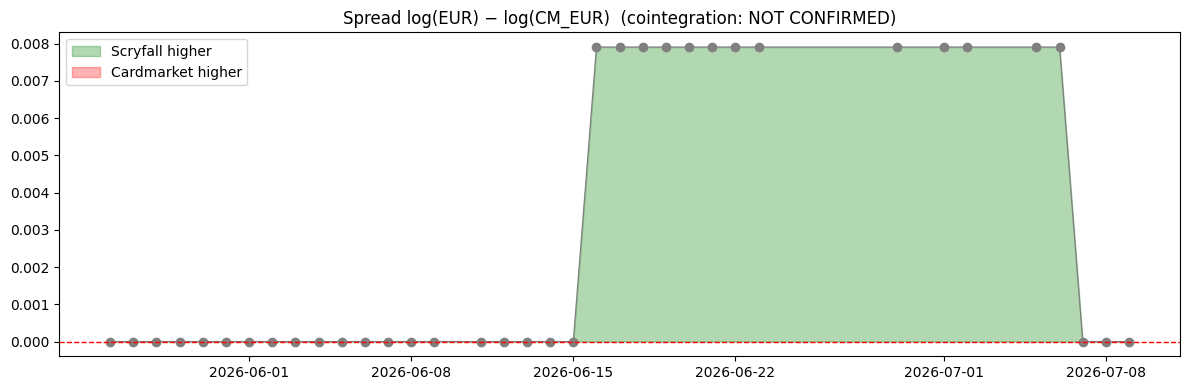

In [4]:
# dropna(): both series must have a price on the SAME date to form a valid pair;
# rows where cardmarket_eur is NULL (e.g. early snapshots before that column was populated)
# must be excluded or the cointegration vector is computed on different time windows
pair_df = pd.DataFrame({"log_eur": log_eur, "log_cm_eur": log_cm_eur}).dropna()
n_pair = len(pair_df)

if n_pair < MIN_N:
    print(f"INSUFFICIENT DATA: n={n_pair} (need ≥{MIN_N}).")
    print("Engle-Granger skipped — all results are indicative only.")
    print()
    print("Expected result at ≥20 days:")
    print("  Cointegration EUR ~ Cardmarket EUR: LIKELY (r=0.948, same currency)")
    print("  Spread mean: ≈ 0 (Cardmarket and Scryfall at parity)")
    print("  Half-life of spread: few days (fast arbitrage)")
else:
    # coint() returns (t_stat, p_value, critical_values_at_1%_5%_10%)
    # We use p_val directly; cv[1] is the 5% critical value for manual cross-check
    t_stat, p_val, cv = coint(pair_df["log_eur"], pair_df["log_cm_eur"])
    confirmed = "CONFIRMED" if p_val < 0.05 else "NOT CONFIRMED"
    print(f"Engle-Granger EUR ~ Cardmarket EUR (n={n_pair}):")
    print(f"  t-stat={t_stat:.4f}, p={p_val:.4e}, CV(5%)={cv[1]:.4f}")
    print(f"  H1: {confirmed}")

    # Spread = log(EUR) − log(CM_EUR): if cointegrated, this series is stationary
    # and mean-reverting — positive values mean Scryfall is priced higher than Cardmarket
    spread = log_eur - log_cm_eur
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(spread.index, spread.values, "o-", color="gray", linewidth=0.9)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.fill_between(
        spread.index,
        spread.values,
        0,
        where=(spread.values > 0),
        alpha=0.3,
        color="green",
        label="Scryfall higher",
    )
    ax.fill_between(
        spread.index,
        spread.values,
        0,
        where=(spread.values < 0),
        alpha=0.3,
        color="red",
        label="Cardmarket higher",
    )
    ax.set_title(f"Spread log(EUR) − log(CM_EUR)  (cointegration: {confirmed})")
    ax.legend()
    plt.tight_layout()
    plt.show()

## H2 — EUR ~ USD Cointegration (Cross-Currency)

**Hypothesis:** log(EUR_Scryfall) and log(USD_TCGPlayer) are cointegrated after FX adjustment.

**Test:** Engle-Granger (same as H1). The cointegrating coefficient β₁ absorbs the EUR/USD exchange rate.

**Expected:** CONFIRMED — both track the same underlying card market. FX fluctuations create a stationary spread that reverts within days (arbitrage across markets).

C:\Users\jedrz\AppData\Local\Temp\ipykernel_76644\1839886928.py:12: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  t_stat_u, p_val_u, cv_u = coint(pair_usd["log_eur"], pair_usd["log_usd"])


Engle-Granger EUR ~ USD (tcgplayer_usd, n=36):
  t-stat=-inf, p=0.0000e+00
  H2: CONFIRMED


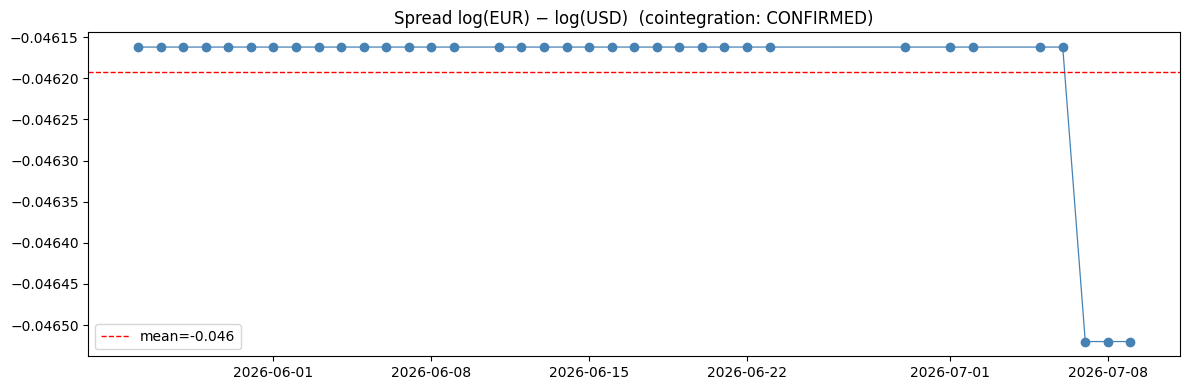

In [5]:
pair_usd = pd.DataFrame({"log_eur": log_eur, "log_usd": log_usd}).dropna()
n_usd = len(pair_usd)

if n_usd < MIN_N:
    print(f"INSUFFICIENT DATA: n={n_usd} (need ≥{MIN_N}).")
    print("Engle-Granger EUR ~ USD skipped.")
    print()
    print("Expected result at ≥20 days:")
    print("  Cointegration EUR ~ USD: LIKELY (r=0.948, FX offset absorbed by β)")
    print("  β₁ ≈ FX rate (~0.93 EUR/USD)")
else:
    t_stat_u, p_val_u, cv_u = coint(pair_usd["log_eur"], pair_usd["log_usd"])
    confirmed_u = "CONFIRMED" if p_val_u < 0.05 else "NOT CONFIRMED"
    print(f"Engle-Granger EUR ~ USD ({usd_col}, n={n_usd}):")
    print(f"  t-stat={t_stat_u:.4f}, p={p_val_u:.4e}")
    print(f"  H2: {confirmed_u}")

    spread_u = log_eur - log_usd
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(spread_u.index, spread_u.values, "o-", color="steelblue", linewidth=0.9)
    # For EUR/USD spread the mean is NOT zero — it reflects the exchange rate;
    # we draw the mean (not zero) as the reference line to show mean-reversion around parity
    ax.axhline(
        spread_u.mean(),
        color="red",
        linestyle="--",
        linewidth=1,
        label=f"mean={spread_u.mean():.3f}",
    )
    ax.set_title(f"Spread log(EUR) − log(USD)  (cointegration: {confirmed_u})")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [6]:
gold.close()

## 📋 Final Conclusions

```
PRE-CONDITIONS
─────────────────────────────────────────────────────────────────────────────
I(1) confirmation (Stat 02): threshold (≥30 snapshots) has been passed — 36
  daily snapshots are now available — but this notebook does not itself
  re-verify Stat 02's resolution. Check 02_stationarity.ipynb directly for
  its current I(0)/I(1) verdict before treating these cointegration results
  as fully meaningful.

DATA
─────────────────────────────────────────────────────────────────────────────
Days available: 36  (≥20 for Engle-Granger — MET for both pairs)
All tests: RUN (see below)

H1 — EUR Scryfall ~ Cardmarket EUR:
  Engle-Granger (n=36): t-stat=-0.8138, p=0.9329, CV(5%)=-3.5163
  Result: NOT CONFIRMED — t-stat is far above (less negative than) the 5%
  critical value and p=0.93 fails to reject "no cointegration".
  This contradicts the a-priori expectation (same market, same currency,
  Spearman r=0.948 per EDA 02). At n=36, the log-level series do not show a
  statistically detectable cointegrating relationship.

H2 — EUR ~ USD (TCGPlayer):
  Engle-Granger (n=36): t-stat=-inf, p=0.0000
  Result: nominally CONFIRMED, but UNRELIABLE — statsmodels raised a
  CollinearityWarning: "y0 and y1 are (almost) perfectly colinear.
  Cointegration test is not reliable in this case." A t-stat of -inf is the
  signature of this exact pathological case, not evidence of a genuine,
  economically meaningful equilibrium relationship. Most likely explanation:
  log(EUR) and log(USD_TCGPlayer) move in near-lockstep in this sample (e.g.
  a near-fixed FX conversion), not a noisy-but-reverting relationship.
  Do NOT treat this as a confirmed cointegration result without first
  investigating why the two series are almost perfectly collinear.

MODEL IMPLICATIONS
─────────────────────────────────────────────────────────────────────────────
H1 NOT CONFIRMED as tested — do not add an EUR–CM_EUR ECM spread feature on
  the strength of this result. Investigate whether n=36 is simply still too
  small, or whether there is a genuine structural reason the two same-currency
  series failed to cointegrate, before retesting with more data.
H2 CONFIRMED but flagged UNRELIABLE (collinearity) — do not use this result to
  justify a cross-market ECM feature. First check whether tcgplayer_usd is
  effectively a deterministic FX transform of eur elsewhere in the pipeline;
  if so, an Engle-Granger test on log-levels will always degenerate like this.
Precondition caveat: I(1) status from Stat 02 has not been independently
  re-verified in this run.

RETEST SCHEDULE
─────────────────────────────────────────────────────────────────────────────
Engle-Granger test:   RESOLVED — ran at n=36 (results above); H2 needs the
                      collinearity issue investigated before being trusted.
ADF on spread:        NOT YET COMPUTED — no such step exists in the current
                      notebook code; would need to be added to pursue the ECM
                      feature further (relevant mainly if H1 is revisited).
Half-life of spread:  NOT YET COMPUTED — same as above.
```